# Лабораторная №2 курса "Синтез Речи"

## Импорты и константы

In [1]:
import csv
from pathlib import Path
import random
import re
import warnings

import jenkspy
import librosa
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from praatio import textgrid
from sklearn.model_selection import train_test_split
from tqdm import tqdm

from pause_predictor import (
    MAX_PAUSE_DURATION,
    NO_PUNCTUATION,
    PausePredictor,
    add_predictions,
    calculate_metrics,
    filter_relevant_rows,
    punctuation_type,
)

In [2]:
warnings.filterwarnings("ignore", category=FutureWarning)
plt.style.use("seaborn-v0_8-whitegrid")

In [3]:
SR = 16000
RANDOM_SEED = 42

In [4]:
RUSLAN_AUDIO_PATH = Path("../../data/RUSLAN/")
RUSLAN_TG_PATH = Path("data/RUSLAN_22050_align_v2/")
RUSLAN_METADATA_PATH = Path("../../data/metadata_RUSLAN_22200_normalized.csv")
RUSLAN_PAUSE_METADATA_PATH = Path("data/RUSLAN_pause_metadata.csv")

In [5]:
def read_tg(tg_path):
    return textgrid.openTextgrid(str(tg_path), includeEmptyIntervals=False)

In [6]:
test_tg_path = RUSLAN_TG_PATH / "000000_RUSLAN.TextGrid"

In [7]:
test_tg = read_tg(test_tg_path)
print(test_tg.tierNames)

('words', 'phones')


## EDA

### Превращаем TextGrid в последовательности для уровней слов и фонем

Намеренно не добавляем начальные паузы (если вдруг есть, но при осмотре не заметил) и конечные, потому что, после прослушивания, появилось убеждение, что паузы между записями не равны реальным паузам между фразами, которые были в оригинальном прочтении

In [8]:
def get_corp_sequence(tier: textgrid.IntervalTier):
    intervals = list(tier.entries)
    sequence = []

    for index, interval in enumerate(intervals):
        sequence.append([interval.start, interval.end, interval.label])

        if index + 1 < len(intervals):
            next_interval = intervals[index + 1]
            if interval.end < next_interval.start:
                sequence.append([interval.end, next_interval.start, ""])

    return sequence

In [9]:
words = []
phones = []

for path in tqdm(sorted(RUSLAN_TG_PATH.glob("*.TextGrid")), disable=True):
    file_id = path.stem
    tg = read_tg(path)
    words_tier = tg.getTier("words")
    phones_tier = tg.getTier("phones")

    if not isinstance(words_tier, textgrid.IntervalTier):
        continue
    if not isinstance(phones_tier, textgrid.IntervalTier):
        continue

    for start, end, label in get_corp_sequence(words_tier):
        words.append([file_id, start, end, end - start, label])

    for start, end, label in get_corp_sequence(phones_tier):
        phones.append([file_id, start, end, end - start, label])

In [10]:
eda_columns = ["file_id", "start", "end", "duration", "label"]

words_df = pd.DataFrame(words, columns=eda_columns)
phones_df = pd.DataFrame(phones, columns=eda_columns)

In [11]:
print(words_df.head())
print()
print(phones_df.head())
print()

         file_id  start   end  duration      label
0  000000_RUSLAN   0.00  0.11      0.11          с
1  000000_RUSLAN   0.11  0.69      0.58  тревожным
2  000000_RUSLAN   0.69  1.31      0.62   чувством
3  000000_RUSLAN   1.31  1.70      0.39     берусь
4  000000_RUSLAN   1.70  1.79      0.09          я

         file_id  start   end  duration label
0  000000_RUSLAN   0.00  0.11      0.11    s̪
1  000000_RUSLAN   0.11  0.18      0.07    t̪
2  000000_RUSLAN   0.18  0.26      0.08    rʲ
3  000000_RUSLAN   0.26  0.27      0.01     ɪ
4  000000_RUSLAN   0.27  0.36      0.09     v



In [12]:
pauses_df = words_df[words_df["label"] == ""].copy()
print(pauses_df.head())

          file_id  start   end  duration label
8   000001_RUSLAN   0.43  0.46      0.03      
17  000002_RUSLAN   1.77  1.80      0.03      
39  000006_RUSLAN   2.44  2.75      0.31      
43  000006_RUSLAN   4.49  4.52      0.03      
48  000007_RUSLAN   0.74  0.85      0.11      


### Mean & std

In [13]:
speech_words_df = words_df[words_df["label"] != ""].copy()
speech_phones_df = phones_df[phones_df["label"] != ""].copy()
letter_count = speech_words_df["label"].str.count(r"[а-яёa-z]")
mean_letter_duration = speech_words_df["duration"].sum() / letter_count.sum()

print(f"Средняя длина паузы: {pauses_df['duration'].mean():.3f} с")
print(f"Средняя длина слова: {speech_words_df['duration'].mean():.3f} с")
print(f"Средняя длина буквы: {mean_letter_duration:.3f} с")
print(f"Средняя длина фонемы: {speech_phones_df['duration'].mean():.3f} с")

Средняя длина паузы: 0.163 с
Средняя длина слова: 0.411 с
Средняя длина буквы: 0.073 с
Средняя длина фонемы: 0.074 с


In [14]:
print(f"std длины паузы: {pauses_df['duration'].std():.3f} с")
print(f"std длины слова: {speech_words_df['duration'].std():.3f} с")
print(f"std длины фонемы: {speech_phones_df['duration'].std():.3f} с")

std длины паузы: 0.155 с
std длины слова: 0.224 с
std длины фонемы: 0.051 с


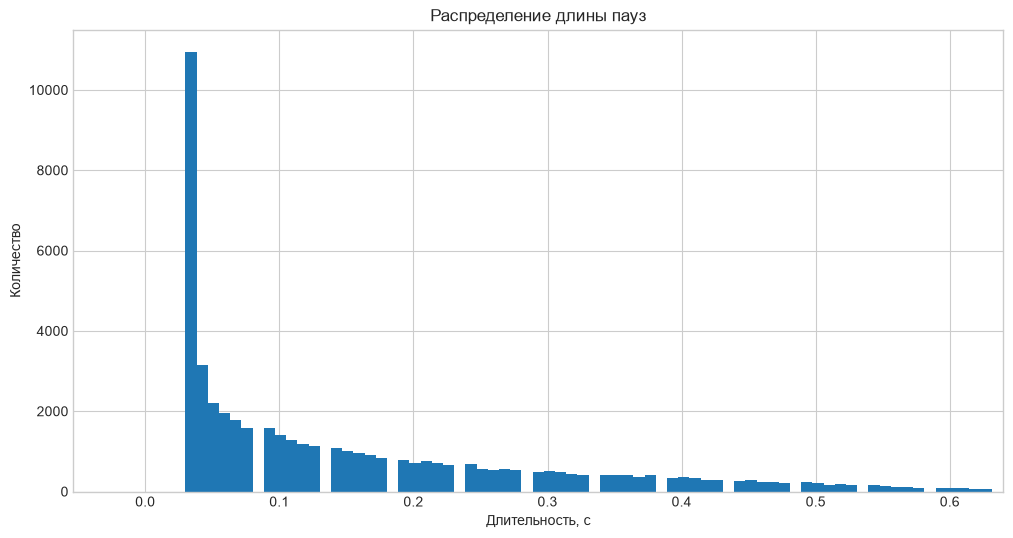

In [15]:
plt.figure(figsize=(12, 6))
plt.xlabel("Длительность, с")
plt.ylabel("Количество")
plt.hist(pauses_df['duration'], bins=200)
plt.xlim(right=np.quantile(pauses_df['duration'], 0.99))
plt.title("Распределение длины пауз")
plt.show()

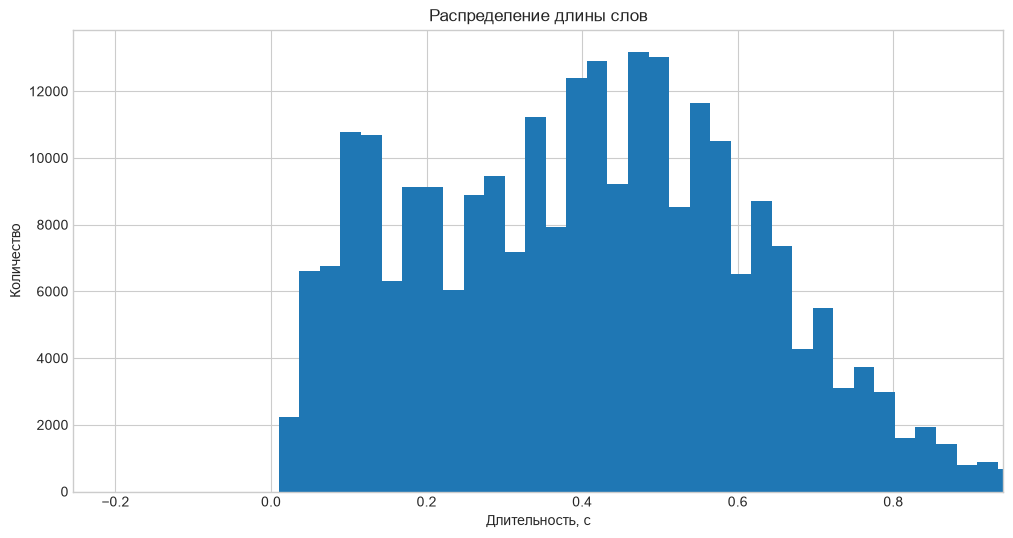

In [16]:
plt.figure(figsize=(12, 6))
plt.xlabel("Длительность, с")
plt.ylabel("Количество")
plt.hist(speech_words_df['duration'], bins=200)
plt.xlim(right=np.quantile(speech_words_df['duration'], 0.99))
plt.title("Распределение длины слов")
plt.show()

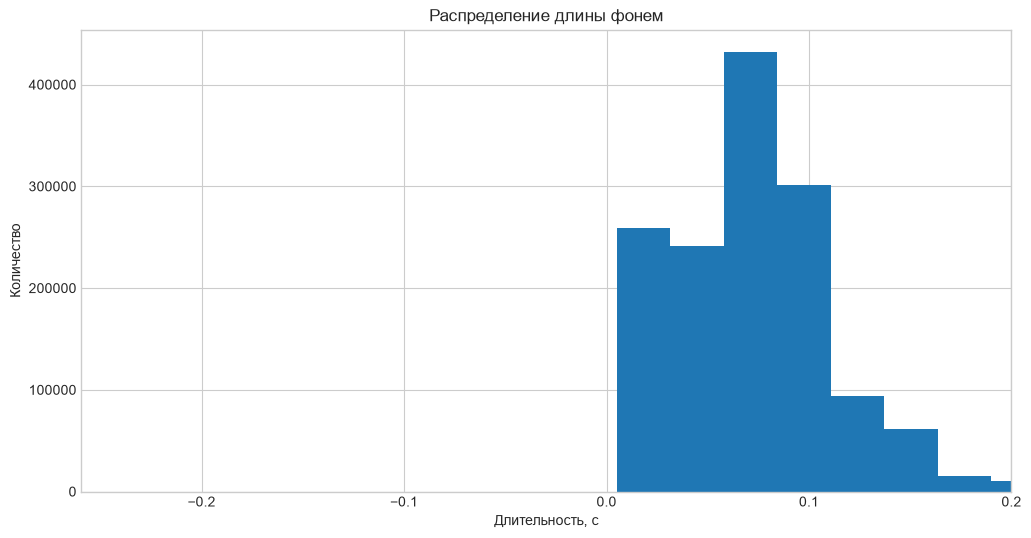

In [17]:
plt.figure(figsize=(12, 6))
plt.xlabel("Длительность, с")
plt.ylabel("Количество")
plt.hist(speech_phones_df['duration'], bins=200)
plt.xlim(right=np.quantile(speech_phones_df['duration'], 0.99))
plt.title("Распределение длины фонем")
plt.show()

In [18]:
phonemes = set(speech_phones_df["label"])
vowels = {
    "a", "e", "i", "o", "u",
    "æ", "ɐ", "ə", "ɛ", "ɨ", "ɪ", "ɵ", "ʉ", "ʊ",
}

In [19]:
phones_vowels_df = phones_df[phones_df["label"].isin(vowels)]
print(phones_vowels_df.head())

          file_id  start   end  duration label
3   000000_RUSLAN   0.26  0.27      0.01     ɪ
5   000000_RUSLAN   0.36  0.47      0.11     o
8   000000_RUSLAN   0.61  0.64      0.03     ɨ
11  000000_RUSLAN   0.82  0.90      0.08     u
15  000000_RUSLAN   1.12  1.13      0.01     ə


In [20]:
print(f"Средняя длина гласной: {phones_vowels_df['duration'].mean():.3f} с")
print(f"std длины гласной: {phones_vowels_df['duration'].std():.3f} с")

Средняя длина гласной: 0.057 с
std длины гласной: 0.049 с


### Предпаузальное удлиннение

In [21]:
previous_words = words_df.groupby("file_id", sort=False).shift(1)
word_pauses_idxs = words_df[words_df["label"] == ""].index

In [22]:
words_before_pauses = previous_words.loc[word_pauses_idxs]
print(words_before_pauses.head())

    start   end  duration       label
8    0.00  0.43      0.43        кого
17   1.33  1.77      0.44         его
39   1.88  2.44      0.56      работу
43   3.80  4.49      0.69  нормальное
48   0.42  0.74      0.32        того


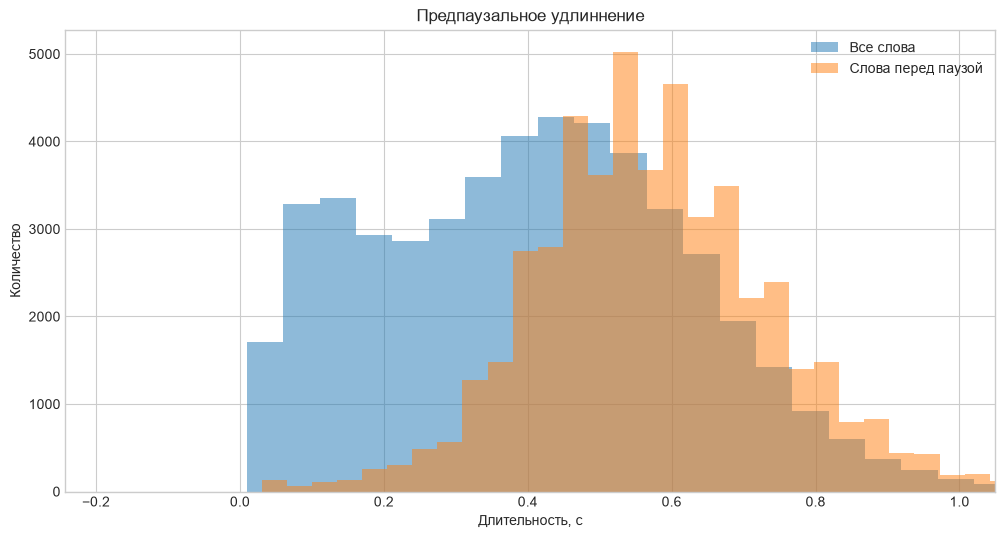

In [23]:
plt.figure(figsize=(12, 6))
plt.xlabel("Длительность, с")
plt.ylabel("Количество")
plt.hist(
    speech_words_df['duration'].sample(
        len(words_before_pauses), random_state=RANDOM_SEED
    ), 
    bins=100, 
    label="Все слова",
    alpha=0.5
)
plt.hist(
    words_before_pauses['duration'], 
    bins=100, 
    label="Слова перед паузой",
    alpha=0.5
)
plt.legend()
plt.xlim(right=np.quantile(words_before_pauses['duration'], 0.99))
plt.title("Предпаузальное удлиннение")
plt.show()

### Jenks Natural Breaks Optimization

In [24]:
pause_length_breaks = jenkspy.jenks_breaks(
    pauses_df["duration"].to_list(),
    n_classes=3
)
print(list(map(float, pause_length_breaks)))

[0.02999799999999908, 0.15000200000000063, 0.36000100000000046, 1.6999999999999997]

Классификация пауз по ЛФШ:

* короткая – около 0,1–0,3 с;
* средняя – около 0,3–0,7 с;
* длинная – более 0,7 с.

Нельзя сказать, что наши классы идеально разделились по этим группам:

* короткая – до 0,15;
* средняя – от 0,15 до 0,36;
* длинная – от 0,36 до 1,7.

### Голос в паузах по RMS

In [25]:
pauses_rms = pd.Series(index=pauses_df.index, dtype=float)

for file_id, file_pauses in tqdm(
    pauses_df.groupby("file_id", sort=False), disable=True
):
    audio_path = RUSLAN_AUDIO_PATH / f"{file_id}.wav"
    audio, _ = librosa.load(audio_path, sr=SR)

    for index, pause_row in file_pauses.iterrows():
        start_sample = int(pause_row["start"] * SR)
        end_sample = int(pause_row["end"] * SR)
        pause_audio = audio[start_sample:end_sample]
        pauses_rms.loc[index] = librosa.feature.rms(y=pause_audio).mean()

/Users/ivanguseff/VScode/tts_labs_itmo/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [26]:
pauses_df.loc[:, "rms"] = pauses_rms
pauses_df["rms"].describe(percentiles=[0.5, 0.9, 0.99])

count    49127.000000
mean         0.001164
std          0.002354
min          0.000024
50%          0.000470
90%          0.002716
99%          0.010099
max          0.101724
Name: rms, dtype: float64

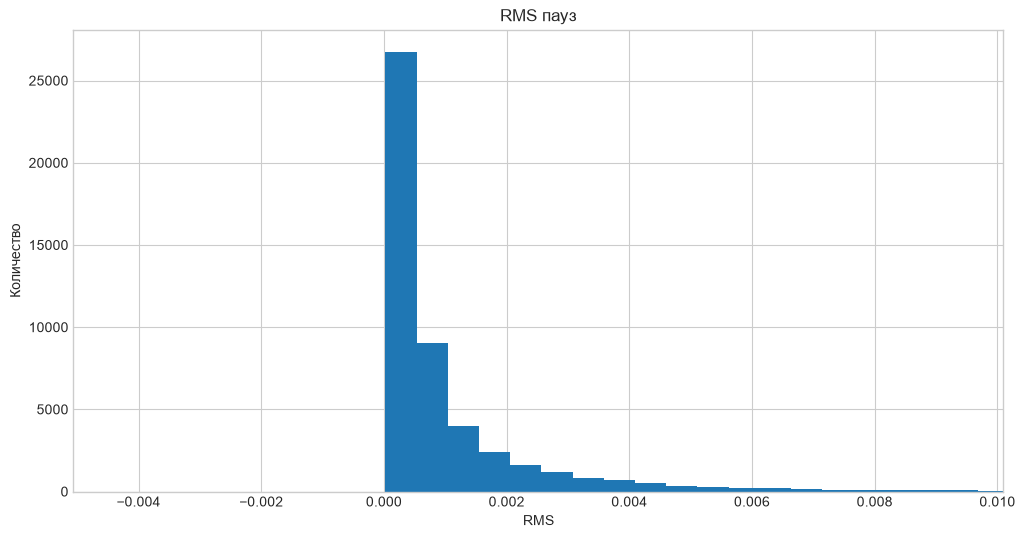

In [27]:
plt.figure(figsize=(12, 6))
plt.xlabel("RMS")
plt.ylabel("Количество")
plt.hist(
    pauses_df["rms"], 
    bins=200,
)
plt.xlim(right=np.quantile(pauses_df["rms"], 0.99))
plt.title("RMS пауз")
plt.show()

## Подготовка данных

Совместим текст из метаданных с интервалами слов из TextGrid. Пунктуацию добавим к предыдущему слову, а информацию о паузах сохраним в `is_pause_after` и `pause_duration`

In [28]:
def normalize_text(text):
    text = text.replace("‐", "-").replace("‑", "-").replace("’", "'")
    return re.sub(r"\([^)]*\)|<[^>]*>", "[bracketed]", text)


def get_raw_labels(labels, text):
    raw_labels = []
    text_lower = text.lower()

    for label in labels:
        parts = text_lower.split(label, maxsplit=1)
        if len(parts) != 2:
            return None

        prefix_length = len(parts[0])
        if raw_labels:
            raw_labels[-1] += text[:prefix_length].strip()
            raw_labels.append(text[prefix_length:prefix_length + len(label)])
        else:
            raw_labels.append(text[:prefix_length + len(label)].strip())

        consumed = prefix_length + len(label)
        text = text[consumed:]
        text_lower = parts[1]

    if raw_labels:
        raw_labels[-1] += text.strip()
    return raw_labels


def prepare_utterance(wave_id, normalized_text):
    tg_path = RUSLAN_TG_PATH / f"{wave_id}.TextGrid"
    if not tg_path.exists():
        return None

    tg = textgrid.openTextgrid(str(tg_path), includeEmptyIntervals=True)
    word_tier = tg.getTier("words")
    if not isinstance(word_tier, textgrid.IntervalTier):
        return None
    intervals = word_tier.entries
    labels = [normalize_text(interval.label) for interval in intervals]
    word_labels = [label for label in labels if label]
    raw_labels = get_raw_labels(word_labels, normalize_text(normalized_text))
    if raw_labels is None:
        return None

    rows = []
    word_index = -1
    for interval, label in zip(intervals, labels):
        duration = float(interval.end - interval.start)
        if label:
            word_index += 1
            rows.append({
                "id": wave_id,
                "label": label,
                "label_raw": raw_labels[word_index],
                "duration": duration,
                "is_last_word": 0,
                "is_pause_after": 0,
                "pause_duration": 0.0,
            })
        elif rows:
            rows[-1]["is_pause_after"] = 1
            rows[-1]["pause_duration"] += duration

    if not rows:
        return None
    rows[-1]["is_last_word"] = 1
    return rows

In [29]:
ruslan_metadata = pd.read_csv(
    RUSLAN_METADATA_PATH,
    sep="|",
    names=["id", "raw", "nrm"],
    dtype=str,
    quoting=csv.QUOTE_NONE,
    keep_default_na=False,
)

pause_rows = []
skipped = 0
for wave_id, normalized_text in ruslan_metadata[["id", "nrm"]].itertuples(index=False):
    utterance_rows = prepare_utterance(wave_id, normalized_text)
    if utterance_rows is None:
        skipped += 1
        continue
    pause_rows.extend(utterance_rows)

pause_metadata = pd.DataFrame(pause_rows)
numeric_id = pause_metadata["id"].str.extract(r"^(\d+)", expand=False).astype(int)
pause_metadata["set"] = np.where(numeric_id.mod(5).eq(0), "test", "train")
pause_metadata = pause_metadata[[
    "id", "label", "label_raw", "duration",
    "is_last_word", "is_pause_after", "pause_duration", "set",
]]

In [30]:
RUSLAN_PAUSE_METADATA_PATH.parent.mkdir(parents=True, exist_ok=True)
pause_metadata.to_csv(
    RUSLAN_PAUSE_METADATA_PATH, sep="|", index=False
)

print(f"Строк: {len(pause_metadata):,}")
print(f"Предложений: {pause_metadata['id'].nunique():,}")
print(f"Пропущено предложений: {skipped}")
print(pause_metadata.head())

Строк: 250,688
Предложений: 21,754
Пропущено предложений: 1
              id      label  label_raw  duration  is_last_word  \
0  000000_RUSLAN          с          С      0.11             0   
1  000000_RUSLAN  тревожным  тревожным      0.58             0   
2  000000_RUSLAN   чувством   чувством      0.62             0   
3  000000_RUSLAN     берусь     берусь      0.39             0   
4  000000_RUSLAN          я          я      0.09             0   

   is_pause_after  pause_duration   set  
0               0             0.0  test  
1               0             0.0  test  
2               0             0.0  test  
3               0             0.0  test  
4               0             0.0  test  


## Предиктор пауз

### Качество разметки и фильтрация

Финальные паузы не используем: они соответствуют границам аудиофайлов. Также отдельно посмотрим на короткие паузы без пунктуации и на редкие выбросы по длительности.

In [31]:
nonfinal_metadata = pause_metadata[pause_metadata["is_last_word"] == 0].copy()
nonfinal_metadata["punctuation"] = nonfinal_metadata["label_raw"].map(punctuation_type)
pause_rows = nonfinal_metadata[nonfinal_metadata["is_pause_after"] == 1]

quality_summary = pd.DataFrame({
    "Количество": [
        len(nonfinal_metadata),
        len(pause_rows),
        pause_rows["punctuation"].eq(NO_PUNCTUATION).sum(),
        pause_rows["pause_duration"].gt(MAX_PAUSE_DURATION).sum(),
        len(nonfinal_metadata) - len(filter_relevant_rows(pause_metadata)),
    ]
}, index=[
    "Нефинальные токены",
    "Паузы",
    "Паузы без пунктуации",
    f"Паузы длиннее {MAX_PAUSE_DURATION:.2f} с",
    "Исключено фильтром",
])
quality_summary

,Количество
Нефинальные токены,228934
Паузы,47990
Паузы без пунктуации,14795
Паузы длиннее 0.48 с,2426
Исключено фильтром,16893


In [32]:
def median_positive_duration(values):
    positive = values[values > 0]
    return positive.median() if len(positive) else np.nan


pause_by_punctuation = (
    nonfinal_metadata
    .groupby("punctuation")
    .agg(
        tokens=("id", "size"),
        pauses=("is_pause_after", "sum"),
        pause_rate=("is_pause_after", "mean"),
        median_duration=("pause_duration", median_positive_duration),
    )
    .sort_values("pauses", ascending=False)
)
punctuation_names = {
    NO_PUNCTUATION: "без знака",
    ".": "точка",
    ",": "запятая",
    "\u2026": "многоточие",
    "\u2014": "тире",
    "?": "вопросительный знак",
    "!": "восклицательный знак",
    "-": "дефис",
    ";": "точка с запятой",
}
pause_by_punctuation.rename(index=punctuation_names).head(10).round(3)

,tokens,pauses,pause_rate,median_duration
punctuation,,,,
без знака,183740,14795,0.081,0.050
точка,14164,13614,0.961,0.180
запятая,20567,11305,0.550,0.090
многоточие,2703,2559,0.947,0.160
тире,3838,2540,0.662,0.140
вопросительный знак,2397,2107,0.879,0.170
восклицательный знак,1165,1033,0.887,0.160
дефис,355,32,0.090,0.205
точка с запятой,5,5,1.000,0.200


У пауз без знака препинания медиана равна примерно 0,05 с. Это похоже на короткие зазоры выравнивания, а не на осмысленную паузацию. Их исключаем из обучения и оценки. Верхнюю границу 0,48 с взяли как 95-й процентиль длительности нефинальных пауз на train. Всего фильтр убирает около 7,4% нефинальных токенов. Test при выборе правил и параметров модели не использовался

### Признаки и модели

Для каждого токена используем тип знака препинания у текущего, предыдущего и следующего токена, длины этих токенов, относительную позицию и длину предложения. Акустическую длительность слова не берём: при синтезе она ещё неизвестна

Место паузы предсказывает логистическая регрессия. Длительность на положительных примерах предсказывает робастная регрессия Хьюбера. Такой подход проще и быстрее эмбеддингов, а используемые признаки можно получить непосредственно из входного текста

### Валидация на части train

In [33]:
train_ids = pause_metadata.loc[pause_metadata["set"] == "train", "id"].unique()
fit_ids, validation_ids = train_test_split(
    train_ids, test_size=0.2, random_state=RANDOM_SEED
)

validation_predictor = PausePredictor().fit(
    pause_metadata[pause_metadata["id"].isin(fit_ids)]
)
validation_predictions = add_predictions(
    pause_metadata[pause_metadata["id"].isin(validation_ids)],
    validation_predictor,
)
pd.Series(calculate_metrics(validation_predictions), name="validation").round(3)

precision    0.785
recall       0.938
f1           0.855
mae          0.098
Name: validation, dtype: float64

### Финальное обучение и оценка

После проверки подхода обучаем модель на всей train-части. Test используем один раз для финальной оценки

In [34]:
pause_predictor = PausePredictor().fit(
    pause_metadata[pause_metadata["set"] == "train"]
)
predicted_metadata = add_predictions(pause_metadata, pause_predictor)

metrics = []
for subset in ["train", "test"]:
    subset_metrics = calculate_metrics(
        predicted_metadata[predicted_metadata["set"] == subset]
    )
    metrics.append({"set": subset, **subset_metrics})

metrics_df = pd.DataFrame(metrics).set_index("set")
metrics_df.round(3)

,precision,recall,f1,mae
set,,,,
train,0.791,0.933,0.856,0.097
test,0.787,0.934,0.854,0.098


### Пример работы предиктора

In [35]:
example_tokens = ["Я", "вернулся.", "Когда", "стемнело."]
tokens_with_pauses, durations_with_pauses = pause_predictor.predict_durations(
    example_tokens
)
pd.DataFrame({
    "token": tokens_with_pauses,
    "duration": durations_with_pauses,
})

,token,duration
0,Я,-1.000000
1,вернулся.,-1.000000
2,<SIL>,0.115065
3,Когда,-1.000000
4,стемнело.,-1.000000


## Выводы

**Что нашли в данных?**

1. Средняя длительность паузы равна 0,163 с, слова 0,411 с, буквы 0,073 с, фонемы 0,074 с, гласной 0,057 с. По Jenks хорошо видны три группы пауз: до 0,15 с, от 0,15 до 0,36 с и длиннее 0,36 с.
2. Паузы сопровождаются предпаузальным удлинением слова
3. Пунктуация является главным наблюдаемым признаком. После точки пауза встречается примерно в 96% случаев, после запятой примерно в 55%
4. Паузы без пунктуации заметно короче: их медиана около 0,05 с. Они похожи на погрешности автоматического выравнивания
5. Медианный RMS пауз равен 0,00047, а 99-й процентиль 0,0101. Большинство интервалов действительно тихие, но у разметки есть небольшой хвост с голосом или шумом

**Что получилось у предиктора?**

На test модель получила F1 около 0,85 и MAE около 0,098 с. Результат достигнут на простых интерпретируемых признаках без эмбеддингов